In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from scipy.stats import chi2_contingency, ttest_ind, mannwhitneyu, normaltest
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

1. Зчитай дані з файлу та виведи інформацію про результати A/B тесту.

In [24]:
tested_data = pd.read_csv('ab_test_data_correct.csv')

In [25]:
tested_data

,user_id,timestamp,test_group,conversion
0,7f6833e6-1141-4f20-b4b2-f1e31019b1fd,2023-07-04 04:40:55.848109,a,0
1,e6a6e960-d3f3-4074-a516-ba1e609b211e,2023-07-06 00:26:45.486187,b,0
2,4d3fbfa5-6847-410a-bac2-477f01d5f400,2023-07-10 20:24:33.639464,b,0
3,361457d9-a044-48f7-981c-d67dc3861679,2023-07-20 07:04:49.957013,b,0
4,285cd63d-7d03-427f-a062-1fa2dd2e77d6,2023-07-19 23:27:50.116680,b,0
...,...,...,...,...
19993,6763ae9a-515c-473e-af00-0d9c4f6a5bc7,2023-07-06 03:27:37.041104,b,0
19994,ac5600f2-4d16-4503-b115-f1a96728b6d1,2023-07-03 04:20:48.572143,a,0
19995,5a8b2630-209b-4d83-b47f-0f3d9dd568a8,2023-07-23 16:23:49.211910,b,1
19996,b572d68b-26ac-432b-9f88-83e0fdee4ca1,2023-07-03 18:26:20.880675,b,0


In [26]:
tested_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     19998 non-null  object
 1   timestamp   19998 non-null  object
 2   test_group  19998 non-null  object
 3   conversion  19998 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 625.1+ KB


In [27]:
tested_data.groupby('test_group').describe()

conversion                                             
                count      mean       std  min  25%  50%  75%  max
test_group                                                        
a             10013.0  0.061021  0.239380  0.0  0.0  0.0  0.0  1.0
b              9985.0  0.089034  0.284806  0.0  0.0  0.0  0.0  1.0

Приведення дати

In [28]:
tested_data['timestamp'] = pd.to_datetime(tested_data['timestamp'])
tested_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19998 entries, 0 to 19997
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   user_id     19998 non-null  object        
 1   timestamp   19998 non-null  datetime64[ns]
 2   test_group  19998 non-null  object        
 3   conversion  19998 non-null  int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 625.1+ KB


2. Кількість користувачів в групах A та B відповідно.

In [29]:
print('\n1. Groups Overview')
print(f'Total users: {len(tested_data)}')
print(tested_data['test_group'].value_counts())


1. Groups Overview
Total users: 19998
test_group
a    10013
b     9985
Name: count, dtype: int64


3. Кількість конверсій в групах A та B відповідно.

In [30]:
# Separate control and variant groups
group_a = tested_data[tested_data['test_group'] == 'a']['conversion']
group_b = tested_data[tested_data['test_group'] == 'b']['conversion']

conversions_a = group_a.sum()
conversions_b= group_b.sum()

print(f'Conversions in Group A: {conversions_a}')
print(f'Conversions in Group B: {conversions_b}')

Conversions in Group A: 611
Conversions in Group B: 889


4. Рівень конверсії в групах A та B відповідно.

In [31]:
conversion_rate_a = conversions_a/len(group_a)
conversion_rate_b = conversions_b/len(group_b)

print(f'Conversion Rate Group A: {conversion_rate_a:.4%}')
print(f'Conversion Rate Group B: {conversion_rate_b * 100:.4f}%') #just for try another option of code

Conversion Rate Group A: 6.1021%
Conversion Rate Group B: 8.9034%


5. Дати початку та кінця тесту, а також тривалість тесту в днях.

In [32]:
start_test = tested_data['timestamp'].min()
finish_test = tested_data ['timestamp'].max()
timedelta = (finish_test - start_test).days

print (f'Date of starting test: {start_test.date()}')
print (f'Date of finishung test: {finish_test:%Y-%m-%d}')
print (f'Duration test: {timedelta} days')

Date of starting test: 2023-07-03
Date of finishung test: 2023-07-25
Duration test: 21 days


6. Розрахунок значення статистики та p-value. 

In [33]:
# Z-test as basic test
alpha = 0.05


n_a = len(group_a)
n_b = len(group_b)

print(f"Peoples in Group A: {n_a}")
print(f"Peoples in Group B: {n_b}")

z_stat, p_val = proportions_ztest(
    count=[conversions_a, conversions_b], # conversions:  А, В from task 3
    nobs=[n_a, n_b] # all people: A, B
)


print(f"  - Z-statistic: {z_stat:.4f}")
print(f"  - P-value: {p_val:.20f}")
print(f"  - Result: {'Statistically significant' if p_val < alpha else 'NOT statistically significant'} (α=0.05)")

Peoples in Group A: 10013
Peoples in Group B: 9985
  - Z-statistic: -7.5197
  - P-value: 0.00000000000005491218
  - Result: Statistically significant (α=0.05)


6.1. T-statistic and p-value (to check results with Z-test and count Effect size)

In [34]:
print("T-TEST ANALYSIS") #Although the data is binary (0/1), according to the Central Limit Theorem, the distribution of means in large samples 
    #(10k+) tends to be normal. I use the Welch test (equal_var=False) because I noticed a difference in the standard deviations of the groups. 
    # This allows us to reliably compare the means (conversion) of both groups.

alpha = 0.05

# Independent samples t-test
t_stat, p_pvalue = ttest_ind(group_a, group_b, equal_var=False)  # Welch's t-test, because std_a != std_b

print(f"Welch's T-Test (unequal variance):")
print(f"  - T-statistic: {t_stat:.4f}")
print(f"  - P-value: {p_pvalue:.20f}")
print(f"  - Result: {'Statistically significant' if p_pvalue < alpha else 'NOT statistically significant'} (α=0.05)")



T-TEST ANALYSIS
Welch's T-Test (unequal variance):
  - T-statistic: -7.5281
  - P-value: 0.00000000000005371630
  - Result: Statistically significant (α=0.05)


In [35]:
# Effect size (Cohen's d)
#Key metrics
mean_a = group_a.mean()
std_a = group_a.std()
n_a = len(group_a) 

mean_b = group_b.mean()
std_b = group_b.std()
n_b = len(group_b)

#pooled_std = np.sqrt((std_a**2 + std_b**2) / 2) #simple formula, because size of groups equal
pooled_std_exect = np.sqrt(((n_a-1)*std_a**2 + (n_b-1)*std_b**2)/(n_a + n_b - 2))
cohens_d = (mean_b - mean_a) / pooled_std_exect
print(f"  - Cohen's d (effect size): {cohens_d:.4f}")
print(f"  - Effect interpretation: ", end="")
if abs(cohens_d) < 0.2:
    print("Small")
elif abs(cohens_d) < 0.5:
    print("Medium")
else:
    print("Large")

  - Cohen's d (effect size): 0.1065
  - Effect interpretation: Small


6.2. Chi-square test for Independence - because Chi test is better for cathegorical data, such as conversion rate

In [36]:
print("CHI-SQUARE TEST (Conversion Rate)") #

# Create contingency table 
a_converted = group_a.sum()
a_not_converted = (group_a == 0).sum()
b_converted = group_b.sum()
b_not_converted = (group_b == 0).sum()

# Create contingency_table
contingency_table = np.array([
    [a_converted, a_not_converted],
    [b_converted, b_not_converted]
])

print("Contingency Table:")
print(pd.DataFrame(contingency_table, 
                   index=['A', 'B'],
                   columns=['Converted', 'Not Converted']))

alpha = 0.05

# Counting Chi 
chi2_stat, chi2_pvalue, dof, expected = chi2_contingency(contingency_table) 


print(f"\nChi-Square Test Results:")
print(f"  - Chi-square statistic: {chi2_stat:.4f}")
print(f"  - P-value: {chi2_pvalue:.20f}")
print(f"  - Degrees of freedom: {dof}")
print(f"  - Result: {'Statistically significant' if chi2_pvalue < alpha else 'NOT statistically significant'} (α=0.05)")

CHI-SQUARE TEST (Conversion Rate)
Contingency Table:
   Converted  Not Converted
A        611           9402
B        889           9096

Chi-Square Test Results:
  - Chi-square statistic: 56.1425
  - P-value: 0.00000000000006740441
  - Degrees of freedom: 1
  - Result: Statistically significant (α=0.05)


7. Візуалізація для порівняння середніх значень у групах з 95% довірчими інтервалами.

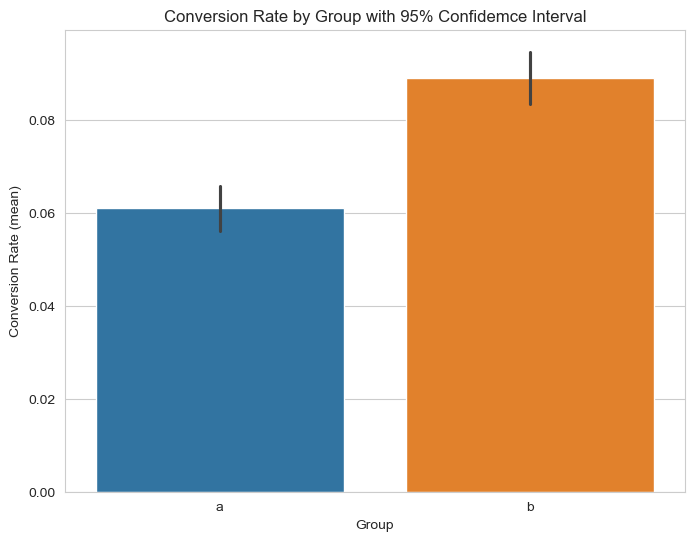

In [37]:
plt.figure(figsize=(8, 6))
sns.set_style("whitegrid") # to add additional lines 

sns.barplot(
    x='test_group', 
    y='conversion', 
    hue = 'test_group',
    data = tested_data,
    errorbar=('ci', 95), # Confidence Intervals
    palette=['#1f77b4', '#ff7f0e']) 

plt.title('Conversion Rate by Group with 95% Confidemce Interval')
plt.xlabel('Group')
plt.ylabel('Conversion Rate (mean)')

plt.show()

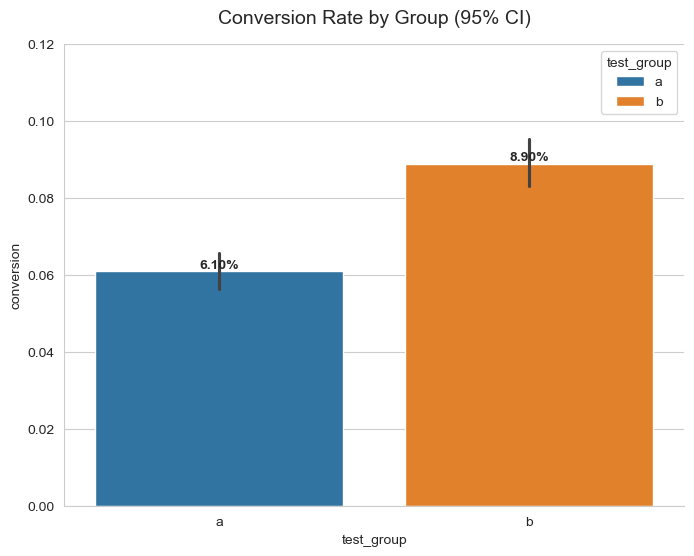

In [38]:
plt.figure(figsize=(8, 6))

ax = sns.barplot(
    x='test_group', 
    y='conversion', 
    hue = 'test_group',
    data = tested_data,
    errorbar=('ci', 95), # Confidence Intervals
    palette=['#1f77b4', '#ff7f0e'], legend = True)

for container in ax.containers:
    ax.bar_label(container, fmt='{:.2%}', fontsize=10, fontweight='bold')

sns.despine()

plt.title('Conversion Rate by Group (95% CI)', fontsize=14, pad=15)
plt.ylim(0, 0.12) 
plt.show()


БОНУС: Графік, що відображатиме зміну конверсії в часі. 


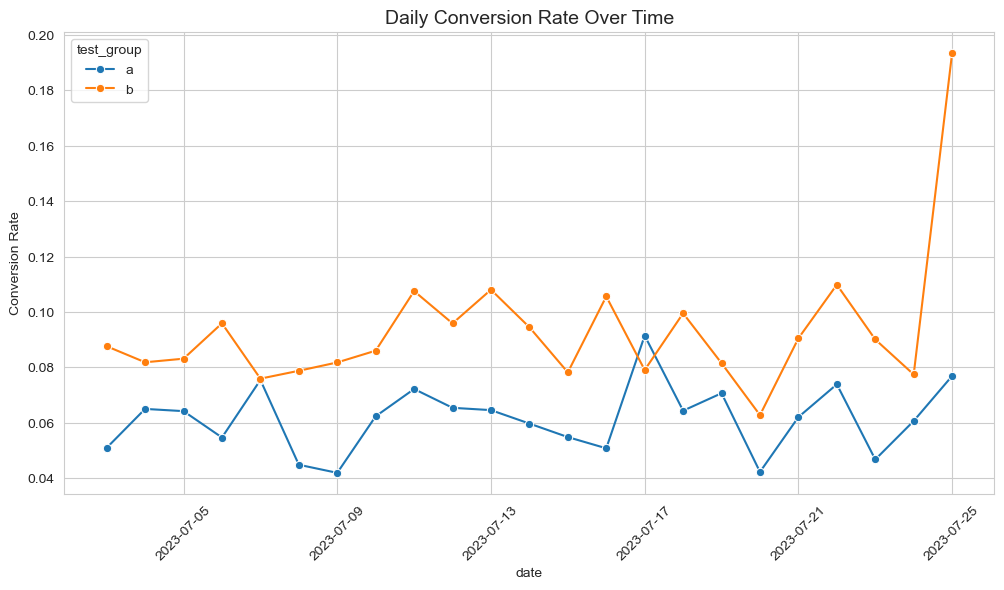

In [39]:
# 1. addict new column with date (without time)
tested_data['date'] = pd.to_datetime(tested_data['timestamp']).dt.date

# 2. Dayly conversion
daily_conversion = tested_data.groupby(['date', 'test_group'])['conversion'].mean().reset_index()

# 3. Lineplot
plt.figure(figsize=(12, 6))
sns.lineplot(x='date', y='conversion', hue='test_group', data=daily_conversion, marker='o')

plt.title('Daily Conversion Rate Over Time', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Conversion Rate')
plt.show()


the same lineplot, but with CI

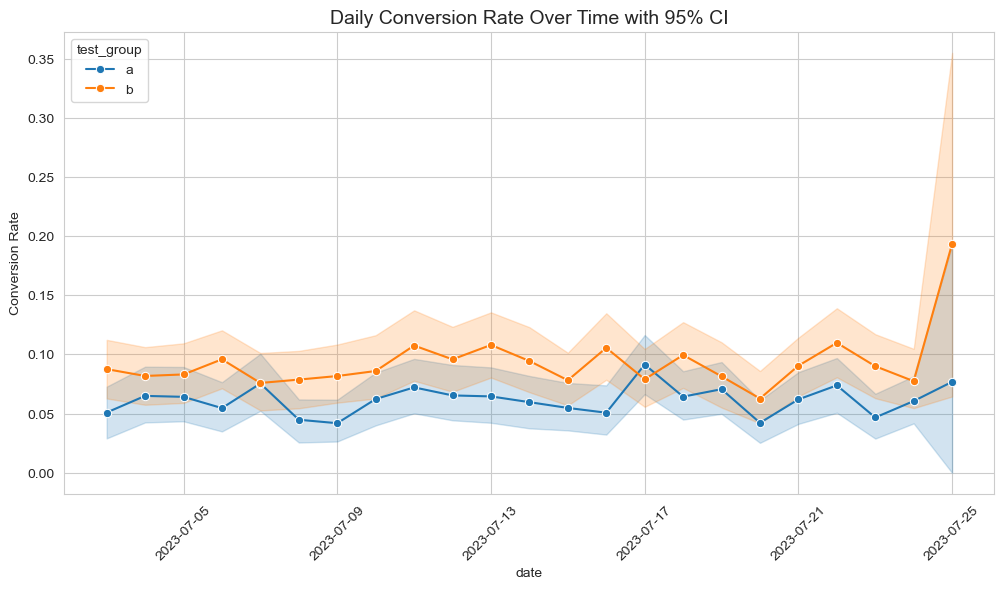

In [41]:
plt.figure(figsize=(12, 6))

# Використовуємо початковий датасет, де є всі 0 та 1
sns.lineplot(x='date', y='conversion', hue='test_group', 
             data=tested_data, marker='o', errorbar=('ci', 95))

plt.title('Daily Conversion Rate Over Time with 95% CI', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Conversion Rate')
plt.show()


Оскільки середнє останнього дня тестування значно "вибивається" , перевіряємо кількість користувачів по днях тесту

In [ ]:
tested_data['date'].value_counts().sort_index()


Графік Конверсія по дням без урахування останнього аномального дня

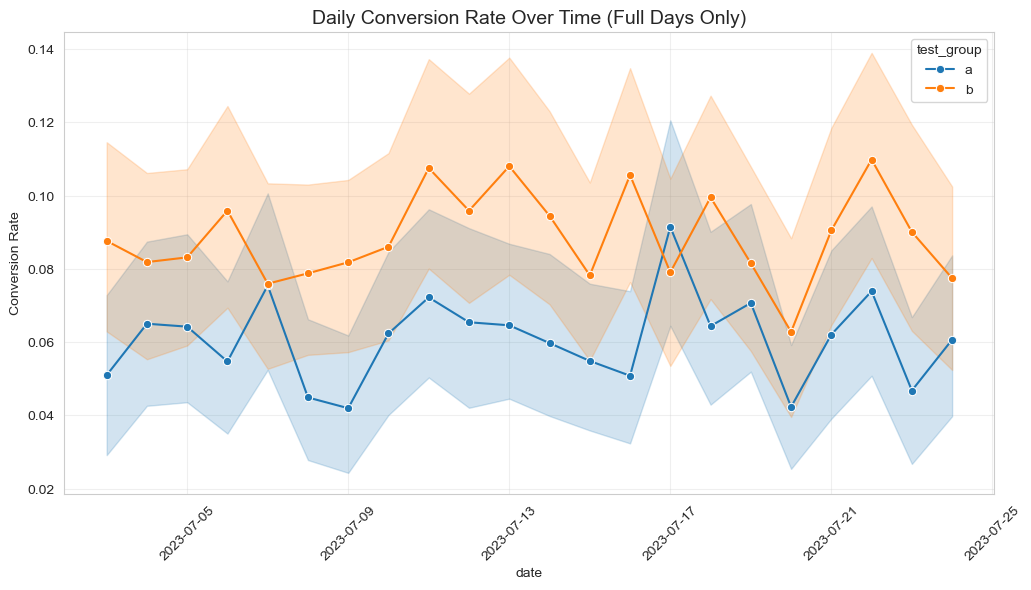

In [42]:
last_day = finish_test.date()

plt.figure(figsize=(12, 6))

sns.lineplot(
    x='date', 
    y='conversion', 
    hue='test_group', 
    data=tested_data[tested_data['date'] < last_day], # only days, less then the last
    marker='o', 
    errorbar=('ci', 95)
)


plt.title('Daily Conversion Rate Over Time (Full Days Only)', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Conversion Rate')
plt.grid(True, alpha=0.3) 
plt.show()


Всі стат показники разом

In [40]:
# Key metrics
mean_a = group_a.mean()
std_a = group_a.std()
conversion_a = (group_a > 0).sum() / len(group_a)

mean_b = group_b.mean()
std_b = group_b.std()
conversion_b= (group_b > 0).sum() / len(group_b)

print("\n2. KEY METRICS")
print("-" * 80)
print(f"A Group:")
print(f"  - Mean: {mean_a:.4f}")
print(f"  - Std Dev: {std_a:.4f}")
print(f"  - Conversion Rate: {conversion_a:.4%}")
print(f"  - Total Users: {len(group_a)}")
print(f"\nB Group:")
print(f"  - Mean: {mean_b:.4f}")
print(f"  - Std Dev: {std_b:.4f}")
print(f"  - Conversion Rate: {conversion_b:.4%}")
print(f"  - Total Users: {len(group_b)}")

print(f"\nDifferences:")
print(f"  - Absolute Сonversion Difference: {mean_b - mean_a:.4f}")
print(f"  - Conversion Rate Lift: {((conversion_b - conversion_a) / conversion_a * 100):.2f}%")


2. KEY METRICS
--------------------------------------------------------------------------------
A Group:
  - Mean: 0.0610
  - Std Dev: 0.2394
  - Conversion Rate: 6.1021%
  - Total Users: 10013

B Group:
  - Mean: 0.0890
  - Std Dev: 0.2848
  - Conversion Rate: 8.9034%
  - Total Users: 9985

Differences:
  - Absolute Сonversion Difference: 0.0280
  - Conversion Rate Lift: 45.91%
